#The Hidden Cost of Higher Education

This project analyzes the value of colleges by examining the relationship between cost, student characteristics, and post-graduation earnings using the College Scorecard dataset. We cleaned and structured the data, filled missing earnings using prior-year data, and created a net price feature to better reflect what students actually pay . Using PCA and clustering, we identified patterns across universities beyond simple categories like public vs private, and built a regression model to predict earnings. While the model captures some trends, much of the variation is driven by factors outside the data. Overall, our findings show that higher cost does not necessarily lead to better outcomes, and that college value is better measured through return on investment.

Import required libraries for data loading and manipulation

In [ ]:
import yaml
import pandas as pd

Load to get metadat info

In [ ]:
with open("data.yaml", "r") as f:
    schema = yaml.safe_load(f)

Build dictionary to rename raw dataset columns into cleaner, more redable names

In [ ]:
csv_to_clean = {
    meta["source"]: clean_name
    for clean_name, meta in schema["dictionary"].items()
    if "source" in meta
}

Load 2024-2025 dataset and apply cleaned column names

In [ ]:
df = pd.read_csv(
    "MERGED2024_25_PP.csv",
    na_values=schema["null_value"],
    low_memory=False
)

df = df.rename(
    columns={k: v for k, v in csv_to_clean.items() if k in df.columns}
)

Load 2022-2023 dataset and apply cleaned column names

In [ ]:
df22 = pd.read_csv(
    "MERGED2022_23_PP.csv",
    na_values=schema["null_value"],
    low_memory=False
)

df22 = df22.rename(
    columns={k: v for k, v in csv_to_clean.items() if k in df22.columns}
)

Extract id and earnings from 2022 dataset

In [ ]:
earn22 = df22[["id", "earnings.4_yrs_after_completion.median"]].copy()

earn22 = earn22.rename(
    columns={"earnings.4_yrs_after_completion.median": "earnings_from_2022"}
)

earn22 = earn22.drop_duplicates(subset=["id"])

Merge the extracted 2022 earnings to 2024 dataset

In [ ]:
before = df["earnings.4_yrs_after_completion.median"].isna().sum()

df = df.merge(earn22, on="id", how="left")

df["earnings.4_yrs_after_completion.median"] = (
    df["earnings.4_yrs_after_completion.median"]
    .fillna(df["earnings_from_2022"])
)

df = df.drop(columns=["earnings_from_2022"])

In [ ]:
after = df["earnings.4_yrs_after_completion.median"].isna().sum()

print("Missing values before:", before)
print("Missing values after:", after)
print("Filled values:", before - after)

print(df[["id", "school.name", "earnings.4_yrs_after_completion.median"]].head())

Missing values before: 6322
Missing values after: 860
Filled values: 5462
       id                          school.name  \
0  100654             Alabama A & M University   
1  100663  University of Alabama at Birmingham   
2  100690                   Amridge University   
3  100706  University of Alabama in Huntsville   
4  100724             Alabama State University   

   earnings.4_yrs_after_completion.median  
0                                 54018.0  
1                                 64969.0  
2                                 50075.0  
3                                 81045.0  
4                                 45998.0  


Keep only important columns for analysis and get descriptive statistics

In [ ]:
cols = [
    "id",
    "cost.tuition.in_state",
    "cost.tuition.out_of_state",
    "admissions.sat_scores.average.overall",
    "admissions.sat_scores.average.by_ope_id",
    "admissions.sat_scores.midpoint.math",
    "admissions.sat_scores.midpoint.writing",
    "admissions.sat_scores.25th_percentile.critical_reading",
    "admissions.sat_scores.75th_percentile.critical_reading",
    "admissions.sat_scores.25th_percentile.math",
    "admissions.sat_scores.75th_percentile.math",
    "aid.federal_loan_rate",
    "repayment.2_yr_default_rate",
    "repayment.3_yr_default_rate",
    "aid.ftft_pell_grant_rate",
    "aid.ftft_federal_loan_rate",
    "earnings.3_yrs_after_completion.working_not_enrolled.overall_count",
    "cost.avg_net_price.consumer.overall_median",
    "earnings.5_yrs_after_completion.median",
    "school.name",
    "school.state",
    "school.city",
    "school.ownership",
    "school.degrees_awarded.highest",
    "student.demographics.avg_family_income",
    "student.demographics.first_generation",
    "student.size",
    "aid.pell_grant_rate",
    "cost.avg_net_price.public",
    "cost.avg_net_price.private",
    "completion.rate_suppressed.four_year",
    "earnings.4_yrs_after_completion.median"
]

cols += [c for c in df.columns if c.startswith("cost.net_price.consumer.by_income_level")]
cols += [c for c in df.columns if c.startswith("academics.program.degree")]
cols += [c for c in df.columns if c.startswith("academics.program.percentage")]


df = df[cols]

print(df.describe())

                 id  cost.tuition.in_state  cost.tuition.out_of_state  \
count  6.322000e+03            3662.000000                3662.000000   
mean   2.217185e+06           17753.961496               21231.100492   
std    7.742673e+06           16350.637495               15353.464437   
min    1.006540e+05               0.000000                   0.000000   
25%    1.742375e+05            5792.500000                9935.000000   
50%    2.290225e+05           11943.500000               16364.000000   
75%    4.589105e+05           23760.000000               28535.000000   
max    4.966450e+07           72097.000000               72097.000000   

       admissions.sat_scores.average.overall  \
count                            1038.000000   
mean                             1184.387283   
std                               148.473818   
min                               720.000000   
25%                              1084.500000   
50%                              1161.000000   
75%   

Calculate missing values to identify unusable features

In [ ]:
avg_missing_data = df.isna().mean().sort_values(ascending=False)
avg_missing_data

,0
admissions.sat_scores.midpoint.writing,1.000000
admissions.sat_scores.midpoint.math,1.000000
repayment.2_yr_default_rate,1.000000
student.demographics.first_generation,1.000000
student.demographics.avg_family_income,1.000000
earnings.5_yrs_after_completion.median,1.000000
cost.avg_net_price.consumer.overall_median,1.000000
earnings.3_yrs_after_completion.working_not_enrolled.overall_count,1.000000
admissions.sat_scores.25th_percentile.math,0.849731
admissions.sat_scores.75th_percentile.math,0.849731


Remove columns with too many missing values (ex.SAT scores and average net price)

In [ ]:
threshold = 0.82
cols_to_drop = avg_missing_data[avg_missing_data > threshold].index

df_reduced = df.drop(columns=cols_to_drop)

In [ ]:
sat_col = "admissions.sat_scores.average.by_ope_id"
public_cost = "cost.avg_net_price.public"
private_cost = "cost.avg_net_price.private"

mask = (
    df_reduced[sat_col].notna() &
    (df[public_cost].notna() | df[private_cost].notna())
)

df_reduced = df_reduced[mask].copy()

avg_missing_data = df_reduced.isna().mean().sort_values(ascending=False)
avg_missing_data
#coincidentally at least for the 22-23 data set removed the all the aid rows that were blank
#also note that school owner ship is described as 1 = pubic, 2 = private, 3 private for profit

,0
cost.avg_net_price.public,0.579190
cost.avg_net_price.private,0.420810
completion.rate_suppressed.four_year,0.029466
earnings.4_yrs_after_completion.median,0.013812
repayment.3_yr_default_rate,0.003683
cost.tuition.in_state,0.001842
cost.tuition.out_of_state,0.001842
id,0.000000
admissions.sat_scores.average.by_ope_id,0.000000
aid.federal_loan_rate,0.000000


Merge public and private net price

In [ ]:
df_reduced["net_price"] = None

df_reduced.loc[
    df_reduced["school.ownership"] == 1,
    "net_price"
] = df_reduced.loc[
    df_reduced["school.ownership"] == 1,
    "cost.avg_net_price.public"
]

df_reduced.loc[
    df_reduced["school.ownership"] != 1,
    "net_price"
] = df_reduced.loc[
    df_reduced["school.ownership"] != 1,
    "cost.avg_net_price.private"
]


df_reduced[[
    "cost.avg_net_price.public",
    "cost.avg_net_price.private",
    "net_price"
]].isna().mean()


,0
cost.avg_net_price.public,0.57919
cost.avg_net_price.private,0.42081
net_price,0.00000


Visualize relationship between tuition and post-graduation earnings

Schools being compared 6322


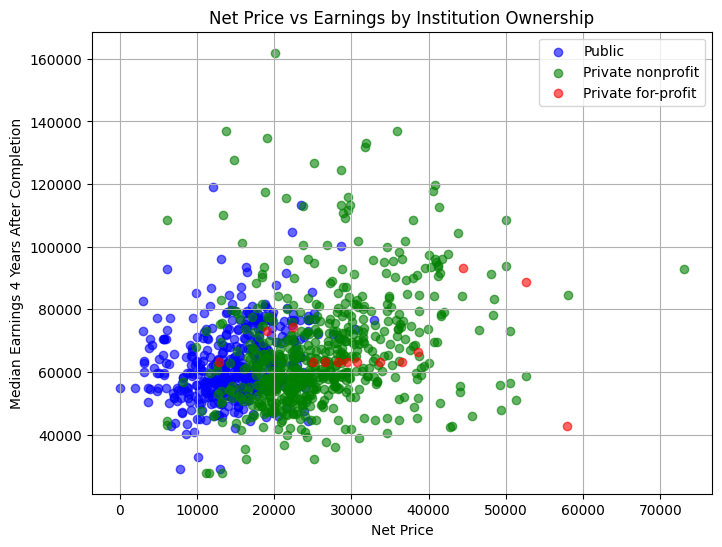

In [ ]:
plot_df = df_reduced[[
    "net_price",
    "earnings.4_yrs_after_completion.median",
    "school.ownership"
]].dropna()
print("Schools being compared",len(df))

import matplotlib.pyplot as plt

color_map = {
    1: "blue",      # Public
    2: "green",     # Private nonprofit
    3: "red"        # Private for-profit
}

label_map = {
    1: "Public",
    2: "Private nonprofit",
    3: "Private for-profit"
}


plt.figure(figsize=(8, 6))

for ownership in sorted(plot_df["school.ownership"].unique()):
    subset = plot_df[plot_df["school.ownership"] == ownership]

    plt.scatter(
        subset["net_price"],
        subset["earnings.4_yrs_after_completion.median"],
        alpha=0.6,
        label=label_map[ownership],
        color=color_map[ownership]
    )

plt.xlabel("Net Price")
plt.ylabel("Median Earnings 4 Years After Completion")
plt.title("Net Price vs Earnings by Institution Ownership")
plt.legend()
plt.grid(True)

plt.show()

Draw correlationship matrix to show relationship between variables using heatmap

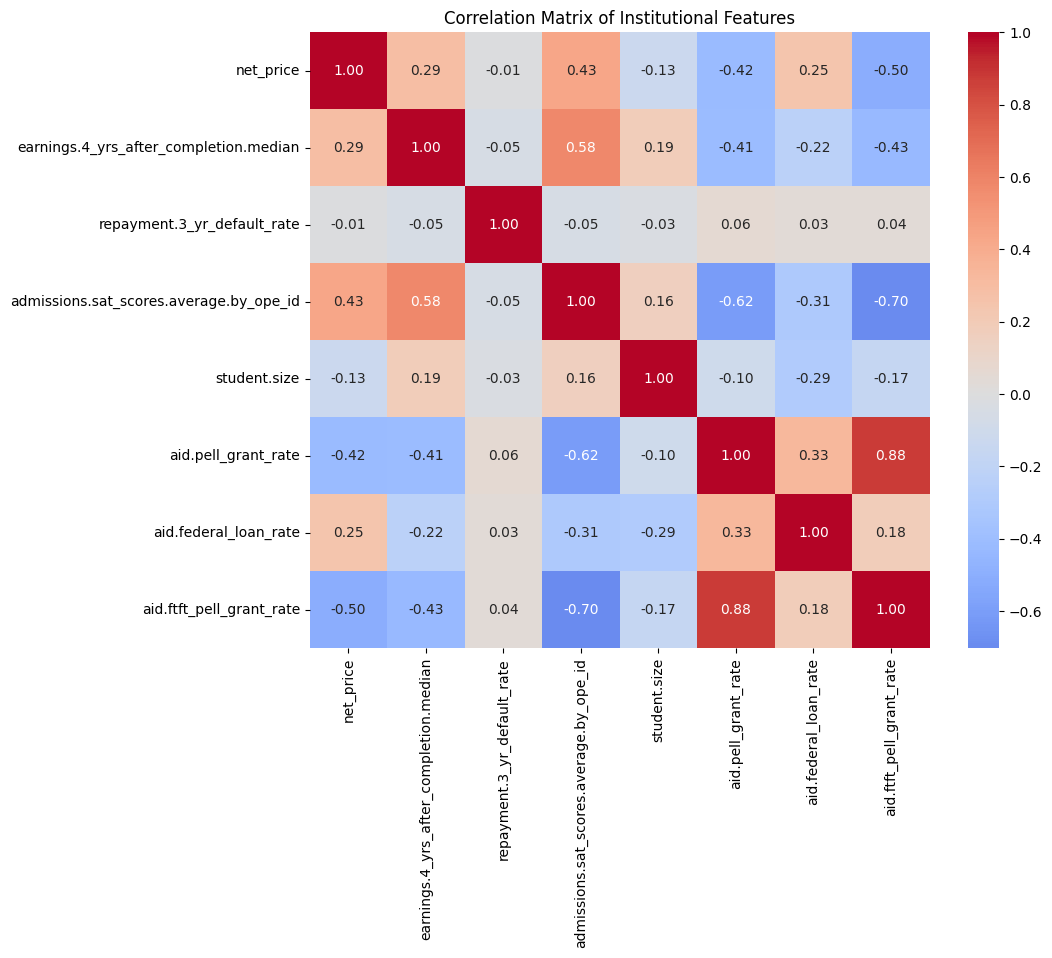

In [ ]:
corr_cols = [
    "net_price",
    "earnings.4_yrs_after_completion.median",
    "repayment.3_yr_default_rate",
    "admissions.sat_scores.average.by_ope_id",
    "student.size",
    "aid.pell_grant_rate",
    "aid.federal_loan_rate",
    "aid.ftft_pell_grant_rate"
]

corr_df = df_reduced[corr_cols].dropna()

corr_matrix = corr_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Institutional Features")
plt.show()

Prepare data PCA
:Select key features, remove missing values for dimensionality reduction, and standardize features

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [
    "net_price",
    "earnings.4_yrs_after_completion.median",
    "repayment.3_yr_default_rate",
    "admissions.sat_scores.average.by_ope_id",
    "student.size",
    "aid.pell_grant_rate",
    "aid.federal_loan_rate",
    "aid.ftft_pell_grant_rate"
]

pca_df = df_reduced[pca_features].dropna()
print(f"Rows used for PCA: {len(pca_df)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)


Rows used for PCA: 1067


Apply PCA and draw Scree plot and PCA scatter plot

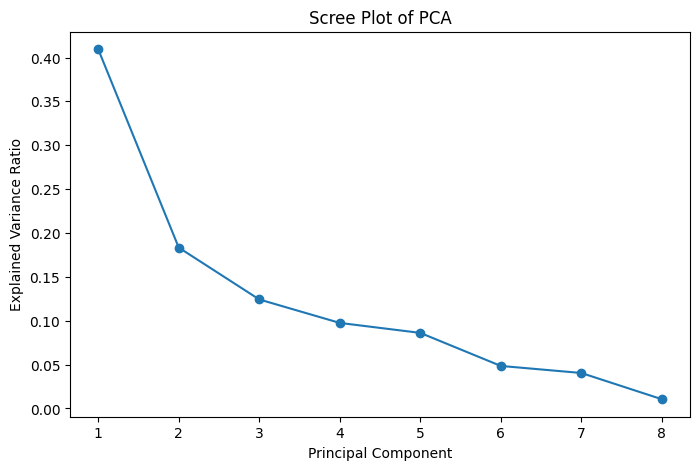

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_var) + 1),
    explained_var,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot of PCA")
plt.show()

pca_plot_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=pca_df.index
)


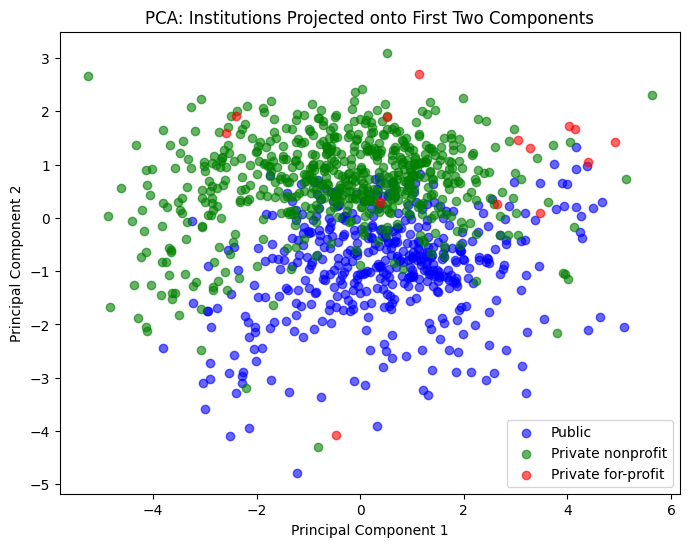

PCA Loadings (PC1 and PC2):


,PC1,PC2
net_price,-0.309134,0.546235
earnings.4_yrs_after_completion.median,-0.374035,-0.077054
repayment.3_yr_default_rate,0.045089,0.063809
admissions.sat_scores.average.by_ope_id,-0.475014,-0.010875
student.size,-0.130048,-0.542417
aid.pell_grant_rate,0.481716,-0.023519
aid.federal_loan_rate,0.196984,0.621936
aid.ftft_pell_grant_rate,0.499096,-0.099632


In [ ]:
pca_plot_df["school.ownership"] = df.loc[pca_df.index, "school.ownership"]

color_map = {1: "blue", 2: "green", 3: "red"}
label_map = {
    1: "Public",
    2: "Private nonprofit",
    3: "Private for-profit"
}

plt.figure(figsize=(8, 6))

for ownership in sorted(pca_plot_df["school.ownership"].unique()):
    subset = pca_plot_df[pca_plot_df["school.ownership"] == ownership]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        color=color_map[ownership],
        label=label_map[ownership]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Institutions Projected onto First Two Components")
plt.legend()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[f"PC{i+1}" for i in range(len(pca_features))]
)

print("PCA Loadings (PC1 and PC2):")
display(loadings[["PC1", "PC2"]])

In [ ]:
df["aid.pell_grant_rate"] > threshold

,aid.pell_grant_rate
0,False
1,False
2,False
3,False
4,False
...,...
6317,False
6318,False
6319,False
6320,False


In [ ]:
df = df.copy()

df["net_price"] = df["cost.avg_net_price.consumer.overall_median"]
df["net_price"] = df["net_price"].fillna(df["cost.avg_net_price.public"])
df["net_price"] = df["net_price"].fillna(df["cost.avg_net_price.private"])

In [ ]:
q = df[[
    "school.name",
    "school.state",
    "aid.pell_grant_rate",
    "completion.rate_suppressed.four_year",
    "earnings.4_yrs_after_completion.median",
    "net_price"
]].dropna().copy()

In [ ]:
q["bang_for_buck"] = (
    q["earnings.4_yrs_after_completion.median"]
    * q["completion.rate_suppressed.four_year"]
) / q["net_price"]

Rank schools with highest ROI(Best value for cost)

In [ ]:
threshold = 0.5

q_high_pell = q[q["aid.pell_grant_rate"] > threshold]

top = q_high_pell.sort_values("bang_for_buck", ascending=False).head(20)

print(top[[
    "school.name",
    "school.state",
    "aid.pell_grant_rate",
    "earnings.4_yrs_after_completion.median",
    "net_price",
    "bang_for_buck"
]].to_string(index=False))

                                       school.name school.state  aid.pell_grant_rate  earnings.4_yrs_after_completion.median  net_price  bang_for_buck
                     CUNY Bernard M Baruch College           NY               0.5688                                 82748.0     3033.0      19.673453
                               CUNY Hunter College           NY               0.5589                                 73236.0     2984.0      14.433677
                             CUNY Brooklyn College           NY               0.5702                                 62833.0     3103.0      11.173461
         CUNY John Jay College of Criminal Justice           NY               0.5979                                 60020.0     3203.0      10.429951
                               CUNY Lehman College           NY               0.5994                                 63353.0     3148.0      10.130845
                                 CUNY City College           NY               0.6054          

The best ROI schools for low-income students are concentrated in a few public systems, especially CUNY

#SUNY vs CUNY ROI

In [ ]:
df = df.copy()

df["net_price"] = (
    df["cost.avg_net_price.consumer.overall_median"]
    .fillna(df["cost.avg_net_price.public"])
    .fillna(df["cost.avg_net_price.private"])
)

cols = [
    "school.name",
    "school.state",
    "school.ownership",
    "earnings.4_yrs_after_completion.median",
    "net_price"
]

q = df[cols].dropna().copy()

In [ ]:
q["roi"] = (
    q["earnings.4_yrs_after_completion.median"] / q["net_price"]
)

def label_system(row):
    name = str(row["school.name"])
    state = row["school.state"]
    ownership = row["school.ownership"]

    if "CUNY" in name:
        return "CUNY"
    elif state == "NY" and ownership == 1:
        return "SUNY"
    else:
        return "Other"

q["system"] = q.apply(label_system, axis=1)

In [ ]:
compare_df = q[q["system"].isin(["SUNY", "CUNY"])].copy()

print("\n=== How many ===")
print(compare_df["system"].value_counts())

summary = compare_df.groupby("system")[[
    "earnings.4_yrs_after_completion.median",
    "net_price",
    "roi"
]].mean().round(2)

print("\n=== ROI Comparison ===")
print(summary)



=== How many ===
system
SUNY    79
CUNY    18
Name: count, dtype: int64

=== ROI Comparison ===
        earnings.4_yrs_after_completion.median  net_price    roi
system                                                          
CUNY                                  57852.17    4504.11  14.11
SUNY                                  55826.77   15261.23   4.43


In [ ]:
top_cuny = (
    compare_df[compare_df["system"] == "CUNY"]
    .sort_values("roi", ascending=False)
    .head(10)
)

print("\n=== Top 10 CUNY ROI Schools ===")
print(top_cuny[[
    "school.name",
    "net_price",
    "earnings.4_yrs_after_completion.median",
    "roi"
]].to_string(index=False))

top_suny = (
    compare_df[compare_df["system"] == "SUNY"]
    .sort_values("roi", ascending=False)
    .head(10)
)

print("\n=== Top 10 SUNY ROI Schools ===")
print(top_suny[[
    "school.name",
    "net_price",
    "earnings.4_yrs_after_completion.median",
    "roi"
]].to_string(index=False))


=== Top 10 CUNY ROI Schools ===
                              school.name  net_price  earnings.4_yrs_after_completion.median       roi
            CUNY Bernard M Baruch College     3033.0                                 82748.0 27.282559
                      CUNY Hunter College     2984.0                                 73236.0 24.542895
                    CUNY Brooklyn College     3103.0                                 62833.0 20.249114
                      CUNY Lehman College     3148.0                                 63353.0 20.124841
CUNY John Jay College of Criminal Justice     3203.0                                 60020.0 18.738682
                        CUNY City College     3776.0                                 67740.0 17.939619
                      CUNY Queens College     4195.0                                 68713.0 16.379738
                        CUNY York College     4456.0                                 61389.0 13.776706
 CUNY New York City College of Technolog

In [ ]:
df = df.copy()

df["net_price"] = (
    df["cost.avg_net_price.consumer.overall_median"]
    .fillna(df["cost.avg_net_price.public"])
    .fillna(df["cost.avg_net_price.private"])
)

cols = [
    "school.name",
    "school.state",
    "school.ownership",
    "school.degrees_awarded.highest",
    "earnings.4_yrs_after_completion.median",
    "net_price"
]

available_cols = [c for c in cols if c in df.columns]
print("Available columns:", available_cols)

q = df[available_cols].copy()

q["school.degrees_awarded.highest"] = pd.to_numeric(
    q["school.degrees_awarded.highest"], errors="coerce"
)
q["earnings.4_yrs_after_completion.median"] = pd.to_numeric(
    q["earnings.4_yrs_after_completion.median"], errors="coerce"
)
q["net_price"] = pd.to_numeric(q["net_price"], errors="coerce")

q = q.dropna(subset=[
    "school.name",
    "school.state",
    "school.ownership",
    "school.degrees_awarded.highest",
    "earnings.4_yrs_after_completion.median",
    "net_price"
]).copy()

Available columns: ['school.name', 'school.state', 'school.ownership', 'school.degrees_awarded.highest', 'earnings.4_yrs_after_completion.median', 'net_price']


In [ ]:
q["roi"] = q["earnings.4_yrs_after_completion.median"] / q["net_price"]

def label_system(row):
    name = str(row["school.name"])
    state = row["school.state"]
    ownership = row["school.ownership"]

    if "CUNY" in name:
        return "CUNY"
    elif state == "NY" and ownership == 1:
        return "SUNY"
    else:
        return "Other"

q["system"] = q.apply(label_system, axis=1)

In [ ]:
q_4yr = q[q["school.degrees_awarded.highest"] >= 3].copy()

compare_4yr = q_4yr[q_4yr["system"].isin(["SUNY", "CUNY"])].copy()

print("\n=== 학교 개수 (4-year only) ===")
print(compare_4yr["system"].value_counts())

summary = (
    compare_4yr.groupby("system")[[
        "earnings.4_yrs_after_completion.median",
        "net_price",
        "roi"
    ]]
    .mean()
    .round(2)
)

print("\n=== SUNY vs CUNY 평균 비교 (4-year only) ===")
print(summary)


=== 학교 개수 (4-year only) ===
system
SUNY    28
CUNY    11
Name: count, dtype: int64

=== SUNY vs CUNY 평균 비교 (4-year only) ===
        earnings.4_yrs_after_completion.median  net_price    roi
system                                                          
CUNY                                  66232.55    4029.27  17.60
SUNY                                  63084.46   16547.86   4.17


In [ ]:
top_cuny = (
    compare_4yr[compare_4yr["system"] == "CUNY"]
    .sort_values("roi", ascending=False)
    .head(10)
    .copy()
)

top_suny = (
    compare_4yr[compare_4yr["system"] == "SUNY"]
    .sort_values("roi", ascending=False)
    .head(10)
    .copy()
)

for t in [top_cuny, top_suny]:
    t["net_price"] = t["net_price"].round(0)
    t["earnings.4_yrs_after_completion.median"] = t["earnings.4_yrs_after_completion.median"].round(0)
    t["roi"] = t["roi"].round(2)

print("\nTop 10 CUNY ROI Schools (4-year only)")
print(top_cuny[[
    "school.name",
    "school.degrees_awarded.highest",
    "net_price",
    "earnings.4_yrs_after_completion.median",
    "roi"
]].to_string(index=False))

print("\n Top 10 SUNY ROI Schools (4-year only)")
print(top_suny[[
    "school.name",
    "school.degrees_awarded.highest",
    "net_price",
    "earnings.4_yrs_after_completion.median",
    "roi"
]].to_string(index=False))


Top 10 CUNY ROI Schools (4-year only)
                              school.name  school.degrees_awarded.highest  net_price  earnings.4_yrs_after_completion.median   roi
            CUNY Bernard M Baruch College                               4     3033.0                                 82748.0 27.28
                      CUNY Hunter College                               4     2984.0                                 73236.0 24.54
                    CUNY Brooklyn College                               4     3103.0                                 62833.0 20.25
                      CUNY Lehman College                               4     3148.0                                 63353.0 20.12
CUNY John Jay College of Criminal Justice                               4     3203.0                                 60020.0 18.74
                        CUNY City College                               4     3776.0                                 67740.0 17.94
                      CUNY Queens College   

In [ ]:
df[df["school.name"] == "Stony Brook University"][[
    "school.name",
    "aid.pell_grant_rate"
]]

,school.name,aid.pell_grant_rate
2144,Stony Brook University,0.3944


#Graph Comparison

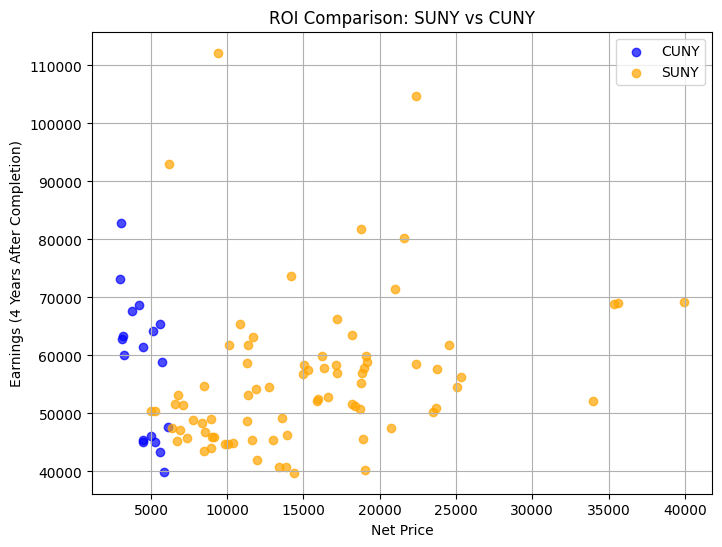

In [ ]:
color_map = {"CUNY": "blue", "SUNY": "orange"}

plt.figure(figsize=(8, 6))

for system in ["CUNY", "SUNY"]:
    subset = compare_df[compare_df["system"] == system]
    plt.scatter(
        subset["net_price"],
        subset["earnings.4_yrs_after_completion.median"],
        alpha=0.7,
        label=system,
        color=color_map[system]
    )

plt.xlabel("Net Price")
plt.ylabel("Earnings (4 Years After Completion)")
plt.title("ROI Comparison: SUNY vs CUNY")
plt.legend()
plt.grid(True)
plt.show()

CUNY: low cost + solid earnings


SUNY: higher cost + mixed outcome

/tmp/ipykernel_1013/3900016296.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


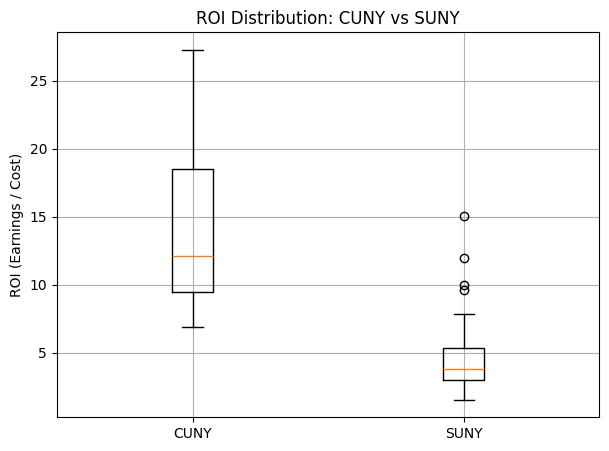

In [ ]:
plt.figure(figsize=(7, 5))

plt.boxplot([
    compare_df[compare_df["system"] == "CUNY"]["roi"],
    compare_df[compare_df["system"] == "SUNY"]["roi"]
], labels=["CUNY", "SUNY"])

plt.ylabel("ROI (Earnings / Cost)")
plt.title("ROI Distribution: CUNY vs SUNY")
plt.grid(True)
plt.show()

In [ ]:
earnings = pd.to_numeric(
    df["earnings.4_yrs_after_completion.median"],
    errors="coerce"
)

print("Mean earnings:", earnings.mean())
print("Std earnings:", earnings.std())
print("Median earnings:", earnings.median())

Mean earnings: 50507.76968143537
Std earnings: 20196.243365570568
Median earnings: 49514.5


Earnings outcomes vary significantly across institutions, with a standard deviation of over $20,000

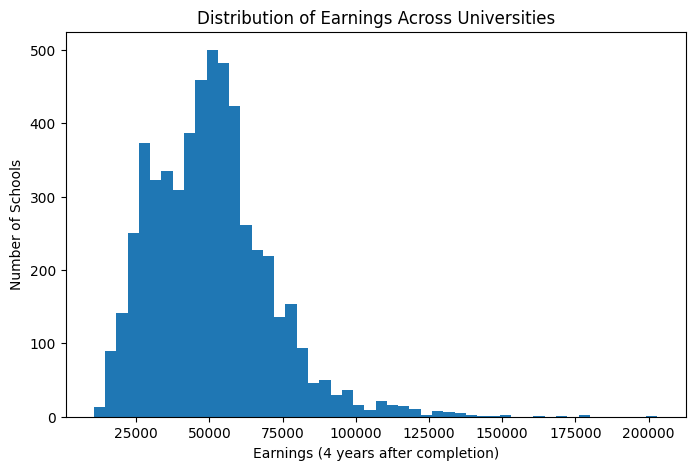

In [ ]:
earnings = earnings.dropna()

plt.figure(figsize=(8, 5))
plt.hist(earnings, bins=50)

plt.xlabel("Earnings (4 years after completion)")
plt.ylabel("Number of Schools")
plt.title("Distribution of Earnings Across Universities")

plt.show()

Most institutions cluster around moderate earnings levels, with a small number of schools achieving significantly higher outcomes

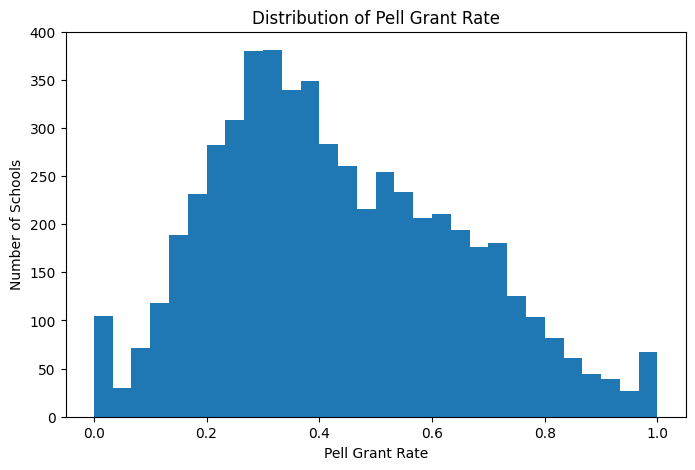

In [ ]:
pell = pd.to_numeric(
    df["aid.pell_grant_rate"],
    errors="coerce"
).dropna()

plt.figure(figsize=(8, 5))
plt.hist(pell, bins=30)

plt.xlabel("Pell Grant Rate")
plt.ylabel("Number of Schools")
plt.title("Distribution of Pell Grant Rate")

plt.show()

A large share of institutions serve significant numbers of low-income students.

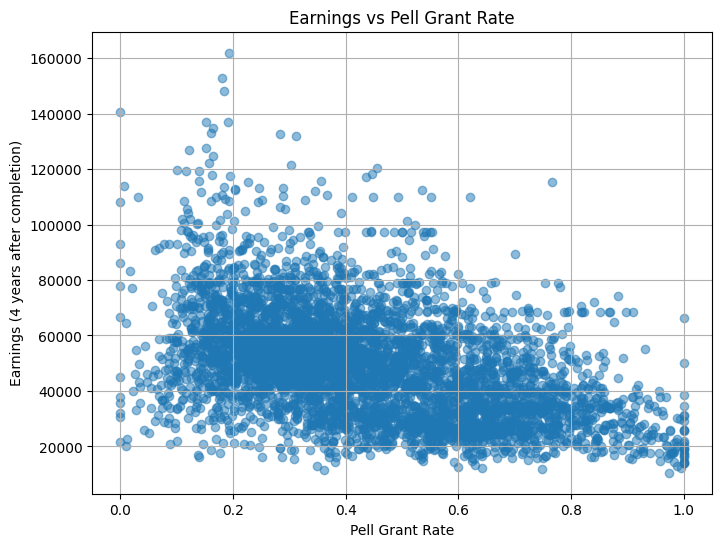

In [ ]:
plot_df = df[[
    "earnings.4_yrs_after_completion.median",
    "aid.pell_grant_rate"
]].dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["aid.pell_grant_rate"],
    plot_df["earnings.4_yrs_after_completion.median"],
    alpha=0.5
)

plt.xlabel("Pell Grant Rate")
plt.ylabel("Earnings (4 years after completion)")
plt.title("Earnings vs Pell Grant Rate")

plt.grid(True)
plt.show()

We observe a clear negative relationship between Pell Grant rates and earnings, with a pronounced ceiling effect at high-Pell institution; High-Pell institutions rarely produce top-earning outcomes

#Using KMeans to estimate groupings of colleges


Tests different numbers of clusters using K-means and evaluates them with silhouette score and Davies-Bouldin index to choose the optimal number of clusters

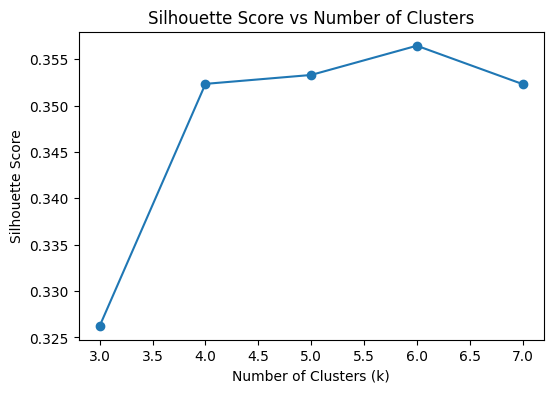

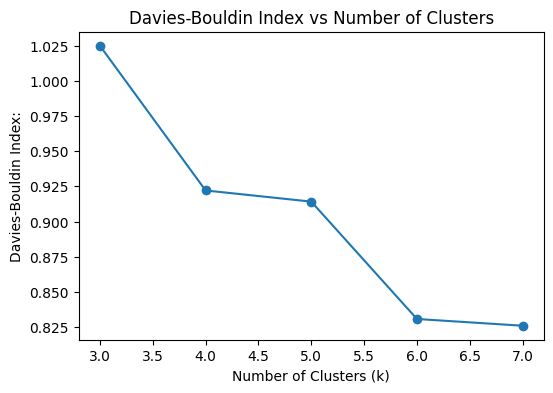

Selected number of clusters (k): 6


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

X_cluster = X_pca[:, :2]

silhouette_scores = {}
davies_bouldin_indices = {}
k_values = range(3, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores[k] = score
    db_index = davies_bouldin_score(X_cluster, labels)
    davies_bouldin_indices[k] = db_index

plt.figure(figsize=(6, 4))
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(
    list(davies_bouldin_indices.keys()),
    list(davies_bouldin_indices.values()),
    marker="o"
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index:")
plt.title("Davies-Bouldin Index vs Number of Clusters")
plt.show()

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Selected number of clusters (k): {best_k}")

Applies K-means with the optimal number of clusters and visualizes the clustered schools in PCA space

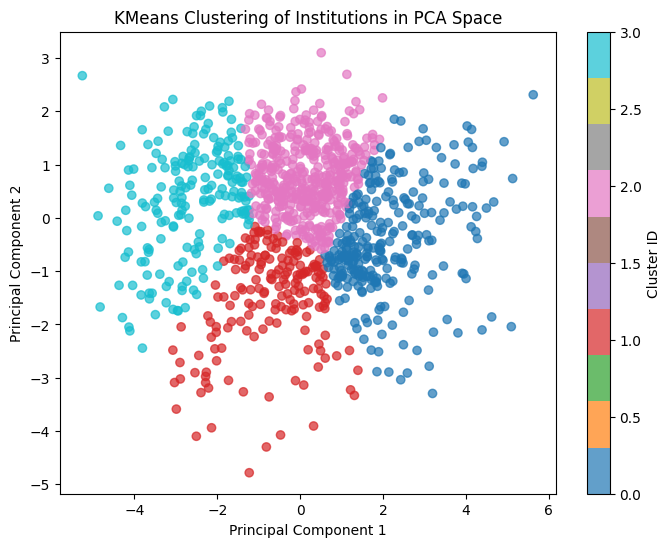

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

cluster_df = pd.DataFrame({
    "PC1": X_cluster[:, 0],
    "PC2": X_cluster[:, 1],
    "cluster": cluster_labels
}, index=pca_df.index)

cluster_df["school.ownership"] = df.loc[pca_df.index, "school.ownership"]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    c=cluster_df["cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering of Institutions in PCA Space")
plt.colorbar(scatter, label="Cluster ID")
plt.show()

What does each cluster look like?

Computes the average key characteristics for each cluster to summarize and compare how different groups of universities behave

In [ ]:
labeled_df = df_reduced.loc[pca_df.index].copy()
labeled_df["cluster"] = cluster_labels

profile_vars = [
    "net_price",
    "admissions.sat_scores.average.by_ope_id",
    "earnings.4_yrs_after_completion.median",
    "repayment.3_yr_default_rate",
    "aid.pell_grant_rate",
    "aid.federal_loan_rate",
    "student.size"
]

cluster_summary = (
    labeled_df
    .groupby("cluster")[profile_vars]
    .mean()
    .round(2)
)
cluster_summary = cluster_summary.rename(
    columns={
        "admissions.sat_scores.average.by_ope_id": "SAT",
        "earnings.4_yrs_after_completion.median": "Earnings",
        "repayment.3_yr_default_rate": "Default Rate",
        "aid.pell_grant_rate": "Pell Grant R",
        "aid.federal_loan_rate": "Loan Rate",
        "student.size": "Student Size"
    }
)

print("Mean values of key variables by cluster:")
display(cluster_summary)

Mean values of key variables by cluster:


,net_price,SAT,Earnings,Default Rate,Pell Grant R,Loan Rate,Student Size
cluster,,,,,,,
0,14061.992674,1039.32,54835.68,0.0,0.46,0.44,4245.46
1,15343.451977,1219.13,68693.18,0.0,0.26,0.30,16575.71
2,23452.175355,1174.77,61608.94,0.0,0.31,0.55,2148.04
3,32294.512821,1388.49,81655.16,0.0,0.17,0.34,5760.33


Groups schools by cluster and calculates the average values of key variables to create a clear profile for each cluster.

In [ ]:
labeled_df = df_reduced.loc[pca_df.index].copy()
labeled_df["cluster"] = cluster_labels

profile_vars = [
    "net_price",
    "admissions.sat_scores.average.by_ope_id",
    "earnings.4_yrs_after_completion.median",
    "repayment.3_yr_default_rate",
    "aid.pell_grant_rate",
    "aid.federal_loan_rate",
    "student.size"
]

cluster_summary = (
    labeled_df
    .groupby("cluster")[profile_vars]
    .mean()
    .round(2)
)
cluster_summary = cluster_summary.rename(
    columns={
        "admissions.sat_scores.average.by_ope_id": "SAT",
        "earnings.4_yrs_after_completion.median": "Earnings",
        "repayment.3_yr_default_rate": "Default Rate",
        "aid.pell_grant_rate": "Pell Grant R",
        "aid.federal_loan_rate": "Loan Rate",
        "student.size": "Student Size"
    }
)

print("Mean values of key variables by cluster:")
display(cluster_summary)

Mean values of key variables by cluster:


,net_price,SAT,Earnings,Default Rate,Pell Grant R,Loan Rate,Student Size
cluster,,,,,,,
0,14061.992674,1039.32,54835.68,0.0,0.46,0.44,4245.46
1,15343.451977,1219.13,68693.18,0.0,0.26,0.30,16575.71
2,23452.175355,1174.77,61608.94,0.0,0.31,0.55,2148.04
3,32294.512821,1388.49,81655.16,0.0,0.17,0.34,5760.33


Counts schools by type within each cluster and converts them into percentages to show the ownership composition of each cluster

In [ ]:
ownership_dist = (
    labeled_df
    .groupby(["cluster", "school.ownership"])
    .size()
    .unstack(fill_value=0)
)

ownership_dist = ownership_dist.rename(
    columns={
        1: "Public",
        2: "Private nonprofit",
        3: "Private for-profit"
    }
)

ownership_pct = ownership_dist.div(ownership_dist.sum(axis=1), axis=0) * 100
ownership_pct = ownership_pct.round(1)

print("Ownership composition (% within each cluster):")
display(ownership_pct)

Ownership composition (% within each cluster):


school.ownership,Public,Private nonprofit,Private for-profit
cluster,,,
0,66.7,30.4,2.9
1,92.7,6.8,0.6
2,21.1,78.2,0.7
3,10.3,88.7,1.0


Counts how many schools are in each cluster and randomly samples a few from each group to inspect representative institutions

In [ ]:
cluster_sizes = labeled_df["cluster"].value_counts().sort_index()
print("Number of institutions per cluster:")
display(cluster_sizes)

sampled_df = (
    labeled_df
    .groupby("cluster", group_keys=False)
    .apply(lambda x: x.sample(n=5, random_state=42))
)


Number of institutions per cluster:


,count
cluster,
0,273
1,177
2,422
3,195


/tmp/ipykernel_1013/888199440.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=5, random_state=42))


#Ivy Leage Comparison
How do schools that we would usually qualitatively group together hold up?

In [ ]:

ivy_leagues = [
    "Brown University",
    "Columbia University in the City of New York",
    "Cornell University",
    "Dartmouth College",
    "Harvard University",
    "University of Pennsylvania",
    "Yale University"
]

suny = {
    "Stony Brook University",
    "University at Buffalo",
    "Binghamton University",
    "CUNY City College",
    "CUNY Queens College"
}

ivy_leagues_subset = labeled_df[
    labeled_df["school.name"].isin(ivy_leagues)
]

print(ivy_leagues_subset[["school.name","cluster"]])

suny_subset = labeled_df[
    labeled_df["school.name"].isin(suny)
]
print(suny_subset[["school.name","cluster"]])

                                      school.name  cluster
557                               Yale University        3
1381                           Harvard University        3
1804                            Dartmouth College        3
1981  Columbia University in the City of New York        3
1986                           Cornell University        3
2754                   University of Pennsylvania        3
2825                             Brown University        3
                 school.name  cluster
1996       CUNY City College        0
2006     CUNY Queens College        1
2142   Binghamton University        1
2143   University at Buffalo        1
2144  Stony Brook University        1


Trains a linear regression model to predict post-graduation earnings using key features and evaluates its performance using RMSE and R^2

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

features = [
    "net_price",
    "admissions.sat_scores.average.by_ope_id",
    "aid.pell_grant_rate",
    "aid.federal_loan_rate",
    "student.size"
]

X = df[features]
y = df["earnings.4_yrs_after_completion.median"]

data = X.join(y).dropna()
X = data[features]
y = data["earnings.4_yrs_after_completion.median"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("R^2:", r2_score(y_test, y_pred))

RMSE: 11875.224697141473
R^2: 0.33510515507823757


Uses 5 fold cross-validation with a pipeline to evaluate model performance more robustly, reporting average RMSE and R^2 along with their variability

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

features = [
    "net_price",
    "admissions.sat_scores.average.by_ope_id",
    "aid.pell_grant_rate",
    "aid.federal_loan_rate",
    "student.size"
]

target = "earnings.4_yrs_after_completion.median"

model_df = df[features + [target]].copy()

model_df = model_df.dropna(subset=[target])

X = model_df[features]
y = model_df[target]

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = -cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="neg_mean_squared_error"
)

rmse_scores = np.sqrt(mse_scores)

r2_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Number of rows used:", len(model_df))
print("Average RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

print()

print("Average R^2:", r2_scores.mean())
print("Std R^2:", r2_scores.std())

Number of rows used: 5462
Average RMSE: 17229.10516155435
Std RMSE: 399.986504422313

Average R^2: 0.27163693615629947
Std R^2: 0.01311066738736245


Fits the model on the full dataset and plots predicted vs actual earnings to visually assess how well the model performs

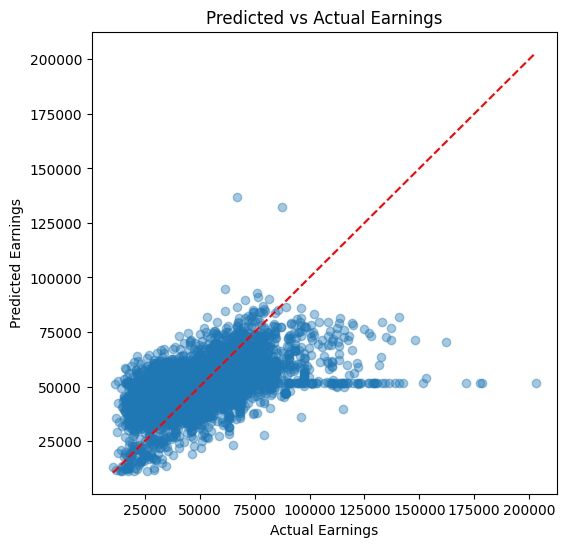

In [ ]:
import matplotlib.pyplot as plt

pipeline.fit(X, y)
y_pred = pipeline.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.4)

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.xlabel("Actual Earnings")
plt.ylabel("Predicted Earnings")
plt.title("Predicted vs Actual Earnings")
plt.show()